In [1]:
import pandas as pd
import os
df_raw =pd.read_csv('std.habits.zip')
df = df_raw.copy() # orignal data 
print("Raw dataset loaded:", df_raw.shape)

Raw dataset loaded: (6607, 11)


### Phase 1 : Cleaning
#### Objective:
##### - Look for errors in  data collection
#### Observation: 
##### - No action taken ; data is in correct data types,has no missing values, and no duplicate rows.
#### Next Step : Visualising.

In [2]:
# studying & analysing our data
print("shape:", df_raw.shape)
print("\n--- Data Types ---")
print(df_raw.dtypes)
print("\n--- Missing Values ---")
print(df_raw.isnull().sum())
print("\n--- Duplicate Rows ---")
print("Duplicates : " , df_raw.duplicated().sum())
print("\n--- Quick Stats ---")
print(df_raw.describe())

print(df.head())

print(df.info())

shape: (6607, 11)

--- Data Types ---
Hours_Studied                 float64
Attendance                    float64
Parental_Involvement           object
Access_to_Resources            object
Extracurricular_Activities     object
Sleep_Hours                   float64
Previous_Scores               float64
Motivation_Level               object
Internet_Access                object
Tutoring_Sessions               int64
Final_Exam_Score              float64
dtype: object

--- Missing Values ---
Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Final_Exam_Score              0
dtype: int64

--- Duplicate Rows ---
Duplicates :  0

--- Quick Stats ---
       Hours_Studied   Attendance  Sleep_Hours  Previous_Scores  \
count    6607

### Phase 2 : Preparing data for visualising
#### Objective:
##### 1.Temporary encoding string data values (i.e Parental_involvement, Access_to_Resources, Extracurricular_Activities, Motivation_Level, and Internet_Access) to numerical
##### 2. To represent string data accurately


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# importing relevant libraries and turned off warnings

In [4]:
df_raw.head(10)  # first 5 rows of our data pre-encoding

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Final_Exam_Score
0,23.5,84.2,Low,Low,Yes,7.4,50.3,Medium,Yes,1,54.3
1,19.7,63.6,Medium,High,Yes,6.7,83.1,Low,Yes,2,59.4
2,24.4,98.4,Medium,Medium,Yes,8.0,63.5,Medium,Yes,0,63.8
3,29.6,88.6,Medium,High,Yes,6.3,57.5,Medium,Yes,2,61.0
4,19.1,91.5,High,Medium,Yes,6.2,66.0,Medium,Yes,2,60.7
5,19.1,88.2,Medium,Medium,Yes,4.8,75.0,Medium,Yes,2,62.3
6,30.0,83.6,Low,High,Yes,7.6,75.2,Low,Yes,1,60.6
7,25.1,78.0,Low,High,Yes,7.5,68.4,Medium,No,0,52.7
8,17.7,94.3,Medium,Low,Yes,8.2,74.7,Medium,Yes,0,56.2
9,23.8,98.3,Medium,High,Yes,7.5,71.4,Low,Yes,1,61.8


In [5]:
#encoding via making a dictionary
Parental_Involvement_Order = {'Low' : 0, 'Medium' : 1, 'High': 2}
df['Parental_Involvement'] = df['Parental_Involvement'].map(Parental_Involvement_Order)
print(df)

Motivation_Level_Order = {'Low' : 0, 'Medium' : 1, 'High': 2}
df['Motivation_Level']= df['Motivation_Level'].map(Motivation_Level_Order)
print(df)

Access_to_Resources_Order = {'Low' : 0, 'Medium' : 1, 'High': 2}
df['Access_to_Resources']= df['Access_to_Resources'].map(Access_to_Resources_Order)
print(df)

Extracurricular_Activities_Order = {'Yes' : 1, 'No' : 0}
df['Extracurricular_Activities']= df['Extracurricular_Activities'].map(Extracurricular_Activities_Order)
print(df)

Internet_Access_Order = {'Yes' : 1, "No" : 0}
df['Internet_Access']=df['Internet_Access'].map(Internet_Access_Order)
print(df)

      Hours_Studied  Attendance  Parental_Involvement Access_to_Resources  \
0              23.5        84.2                     0                 Low   
1              19.7        63.6                     1                High   
2              24.4        98.4                     1              Medium   
3              29.6        88.6                     1                High   
4              19.1        91.5                     2              Medium   
...             ...         ...                   ...                 ...   
6602           26.0        69.5                     2              Medium   
6603           23.0        75.9                     2                 Low   
6604           20.1        90.3                     2                 Low   
6605           10.3        86.0                     2                High   
6606           15.6        67.1                     0              Medium   

     Extracurricular_Activities  Sleep_Hours  Previous_Scores  \
0         

In [6]:
df.dtypes #checking that all data is in numbers now

Hours_Studied                 float64
Attendance                    float64
Parental_Involvement            int64
Access_to_Resources             int64
Extracurricular_Activities      int64
Sleep_Hours                   float64
Previous_Scores               float64
Motivation_Level                int64
Internet_Access                 int64
Tutoring_Sessions               int64
Final_Exam_Score              float64
dtype: object

In [7]:
df.head() #first 5 rows of our encoded data (all data is in numbers now)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Final_Exam_Score
0,23.5,84.2,0,0,1,7.4,50.3,1,1,1,54.3
1,19.7,63.6,1,2,1,6.7,83.1,0,1,2,59.4
2,24.4,98.4,1,1,1,8.0,63.5,1,1,0,63.8
3,29.6,88.6,1,2,1,6.3,57.5,1,1,2,61.0
4,19.1,91.5,2,1,1,6.2,66.0,1,1,2,60.7


### Chart 1: Correlation Heatmap - comparing all numerical columns with final exam score
**Reason for using this chart:** To identify which numerical factor affects final exam score the most

**Expected Result:** Hours studied would directly correlate to  final exam score

**Results Found:** a)Final Exam score has the highest correlation Previous Score at 0.65, b) then with hours studied at 0.41, c) then with attendance at 0.27. d) All other factors are near zero.
            
**Analysed Result:** Prevous exam scores are the biggest factor is determining final exam score.

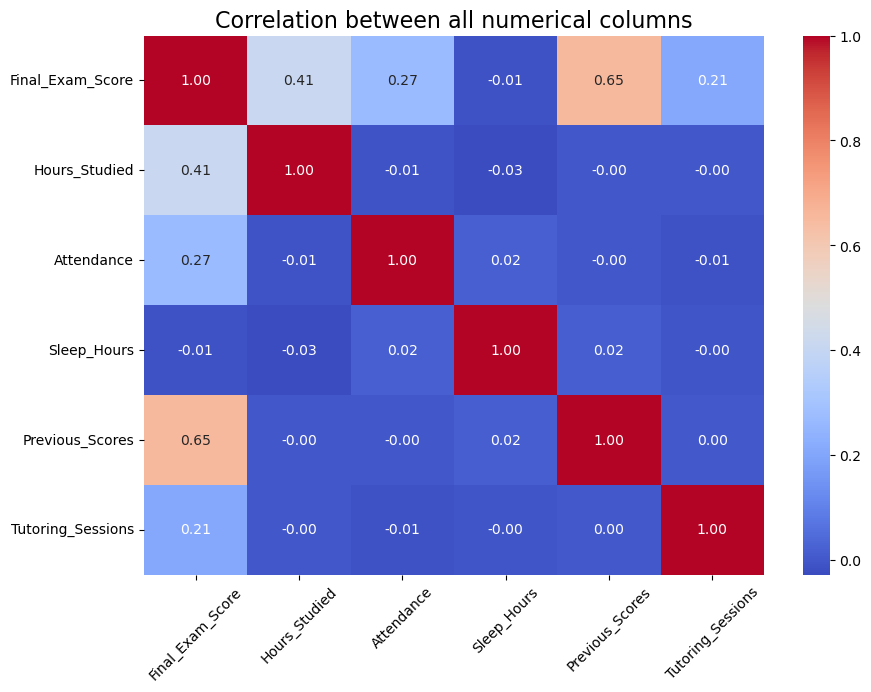

In [8]:
corr_matrix = (df[['Final_Exam_Score','Hours_Studied', 'Attendance', 'Sleep_Hours' ,'Previous_Scores','Tutoring_Sessions']].corr())
    

plt.figure(figsize=(10,7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation between all numerical columns', fontsize=16)
plt.xticks(rotation = 45)
plt.show()

### Chart 2: distribution charts - comparing all numerical columns with final exam score
**Reason for using this chart:** To identify whether students study uniformly or cluster around a certain hour range.

**Expected Result:** I expect most students to score average marks, most students spend less that 5 hours studying, most students sleep around 8-10 hours

**Results Found:** a) More then 350 students score around 62. b)Almost all students (400) study for 20 hours.Most students sleep for 7.2 hours.
            
**Analysed Result:** Final exam score follows a perfect bell curve, its normal and not skewerd insinuating data follows predictable percntage distribuition across standard deviation ; meaning most student did score in the middle range of score. Left skewing bar graph of hours studied suggests most students study in the lower half of 40 hours i.e around 20 hours this is also where the mean of the graph is. Sleep bar being skewed slightly towards the right suggests that most students fall in the late quarter of the 10 hr range while most students fall in the middle category only some deviating the bell curve.

<Figure size 640x480 with 0 Axes>

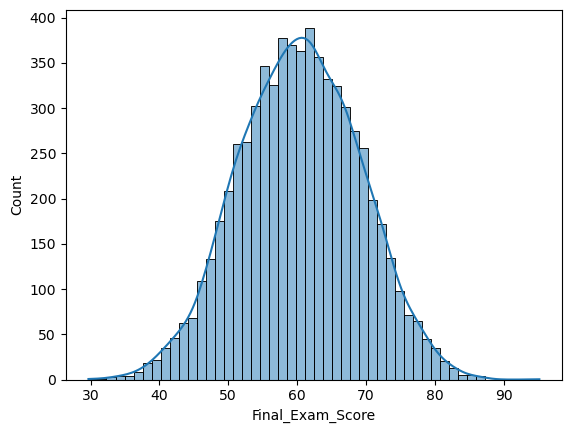

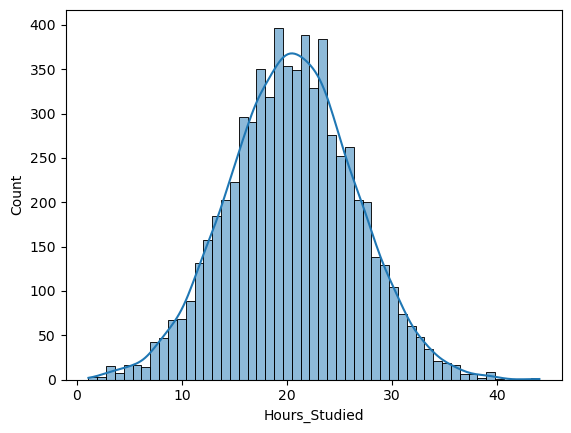

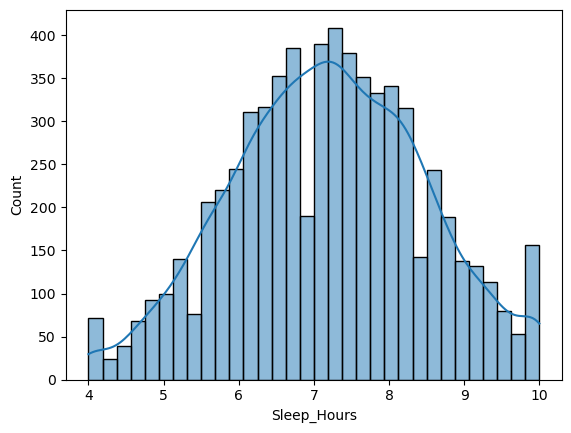

<Figure size 640x480 with 0 Axes>

In [9]:
# final exam score distribution
sns.histplot(df['Final_Exam_Score'], kde=True)
plt.ylabel =('Students')
plt.figure()

sns.histplot(df['Hours_Studied'], kde=True)
plt.yaxis=('Students')
plt.figure()
    
sns.histplot(df['Sleep_Hours'],kde=True)
plt.yaxis=('Students')
plt.figure()

## Chart 3: Bar Charts - final exam score vs parental involvement,access to resources, and motivation level
**Reasons for using these charts:** determining which factor impacts final exam score the most

**Expected Results:** I expect access to resources to affect the final exam score the most

**Results Found:** Different levels of  Parental involvement all resulting in the same size bars, due to their mean being ~ 60

Access to resources show a directly proportional relationship with final exam score. 

The same pattern is seen in motivation level and exam score, although the difference in bars is more drastic.

**Analysed Result:** Initial expected result holds partial truth.

Motivation level 
---
- shows the most difference in final exam score, students with low motivation scored around 57 whereas students with high motivation scored more then 65.This is the most affecting factor in exam score.

- difference between max and minimum score : 65 - 57 = 8

Access to resources
---
- Theres a correlation with final exam score, students with less access scoring around 58, and students with more access more then 60.
- difference between max and minimum score : 60 -58 = 2

Parental Involvement
---
-This is the least affecting factor, the mean is same across all levels

**Finally:**
---
The factor affecting final exam score is Motivation level ; the difference between max and min values being 8, which is the most amongs all three graphs. 

**Note:** It might be noted and food for thought that although motivation level is the most affecting factor, motivation in pupils is produced and sustained due to a variety of combination determined by monetary and emotional support provided to the pupils, this dataset fails to accurately measure the wellness of a student which may not be determined by any of the factors listed.


In [10]:
df_raw.groupby('Parental_Involvement')['Final_Exam_Score'].mean()

Parental_Involvement
High      60.251728
Low       60.499372
Medium    60.449747
Name: Final_Exam_Score, dtype: float64

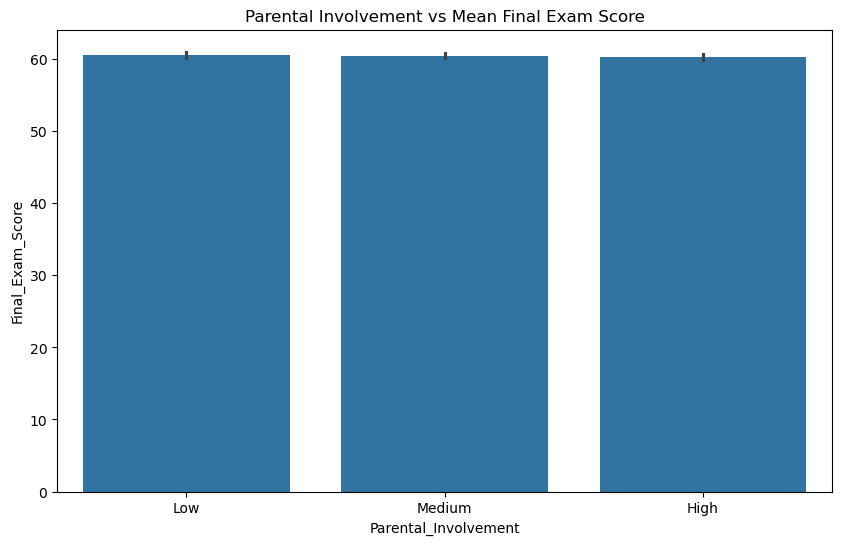

In [11]:
plt.figure(figsize=(10,6))
sns.barplot(data=df_raw, x='Parental_Involvement', y='Final_Exam_Score',order=['Low', 'Medium', 'High'])
plt.title('Parental Involvement vs Mean Final Exam Score')
plt.show()

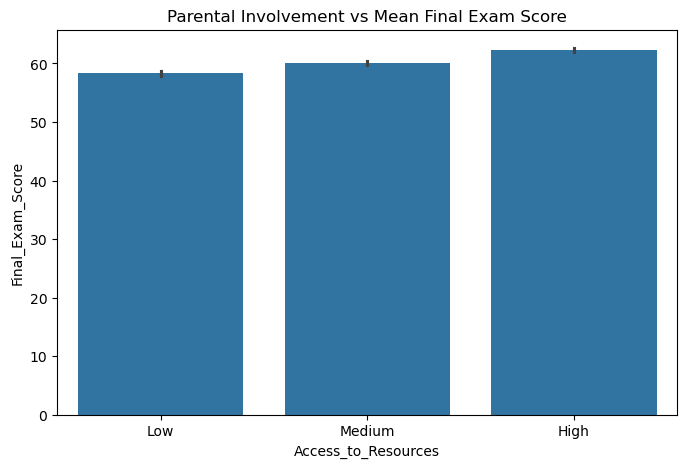

In [12]:
plt.figure(figsize=(8,5))
sns.barplot( data=df_raw,x='Access_to_Resources', y='Final_Exam_Score', order = ['Low', 'Medium', 'High'])
plt.title('Parental Involvement vs Mean Final Exam Score')
plt.show()

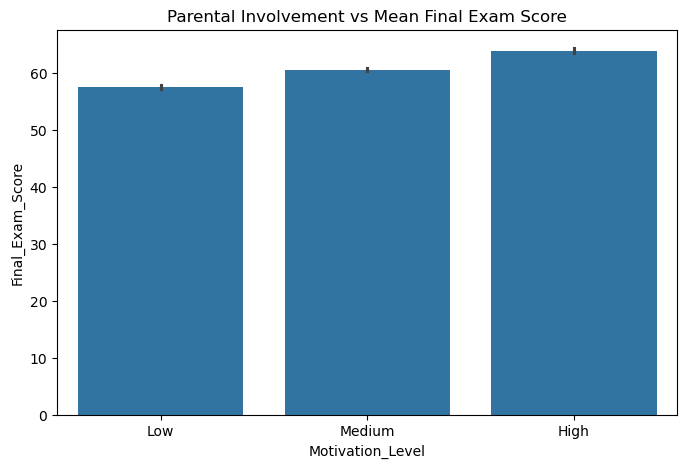

In [13]:
plt.figure(figsize=(8,5))
sns.barplot( data=df_raw,x='Motivation_Level', y='Final_Exam_Score', order = ['Low', 'Medium', 'High'])
plt.title('Parental Involvement vs Mean Final Exam Score')
plt.show()

In [14]:
df_raw['Parental_Involvement'].unique()

array(['Low', 'Medium', 'High'], dtype=object)

## Chart 4 : Scatter plot - Relationship between hours studied and exam score
***Reason For using this chart:*** To understand the relationship between students' exam score and the hours they spent studying and to catch outliers that get missed by other graphs

***Expectation:*** A direct correlation between exam score and hours studied.

***Results Found:*** Most students who studied more did score more and hence opposite but there are as expected some outliers.

1 student scored more then 90 marks (highest) just by studying for ~29 hours, which is the same number of hours that vast majority students achieving scores between 44-84 spent.

Student studying < 5 hours scored the less than 30 marks (lowest) but multiple students scored between 35-65 spending the same hours.

***Analysis:*** The graph generally suggests that students who study more do score more but the outliers suggest that there are other factors too which affect the students' performance in final exam, we know from out analysis and heatmap that the most accurate predicting factor remains to be motivation level of student and this chart confirms our analysis ; hours studied is not the most determining factor.


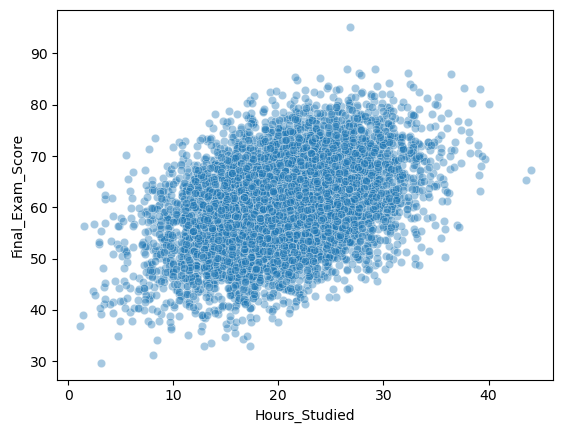

<Figure size 1000x700 with 0 Axes>

In [15]:
sns.scatterplot(data=df, x='Hours_Studied',y='Final_Exam_Score',alpha=0.4) #
plt.figure(figsize=(10,7))
plt.show()


## Chart 5: Line Graph - mean exam score vs hours studied
***Reason For Using This graph:*** Relationship between mean score of students and the hours they spent studying ; to predict the factor which makes students succeed

***Expectations:*** The higher the time spent studying the better the score

***Results Found:*** Theres a direct proportionality between score and hours studied but that doesn't apply for students scoring in the top percentile ie. in the 90-100 range.
Students in the 90-100 range studied less than (<27 hrs) students scoring in the 80-90 range(>27 hours)
Mean score from 50-90 studied for a mean hours of 19-27

***Analysis:*** Further confirmation of our previous hypothesis : hours spent studying , is indeed a important factor in determining students' success but it isn't the most important one as we can see the students scoring in the top percentile didn't study the most hours as one would've assumed.

<Axes: xlabel='Score_Bucket'>

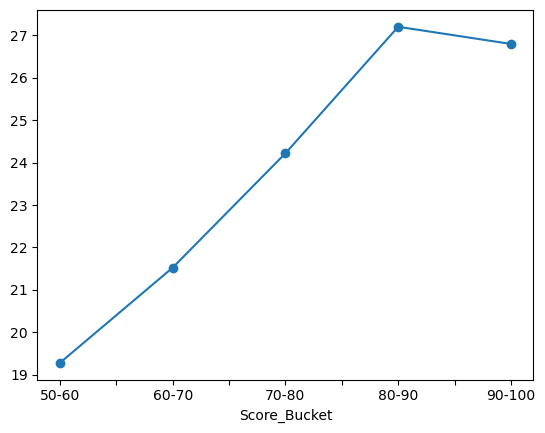

In [16]:
df['Score_Bucket'] = pd.cut(df['Final_Exam_Score'],
                            bins=[50,60,70,80,90,100],
                            labels=['50-60', '60-70', '70-80' , '80-90', '90-100'])
bucket_avg = df.groupby('Score_Bucket')['Hours_Studied'].mean()

bucket_avg.plot(kind='line', marker='o')

## Chart 6: Box Plots - motivation level vs final exam score
***Reason for using this chart:*** To understand how much final exam score is affected by students' motivation levels.

***Expectations:*** High motivation should result in higher score and vice versa.

***Results Found:*** Initial analysis still holds but with a caveat ; there are noticable outliers. 

Score : 52 - 62, Motivation level : low. But some students with the same motivation level scored less than 35 and and also more than 80.

Score : 54 - 64, Motivation level : Medium. But some students with the same motivation level scored ~ 30 and > 80 too.

Score : 57 - 67, Motivation level : High. But some students with the same motivation level scored from ~35 to > 90.

***Analysis:*** It will be mostly accurate to determine a student success based on their motivation levels and this hypothesis is consisitent through all 3 box plots, the outliers explain the value of other factors too but it seems consistent to hypothesize that motivation level shows a modest effect on scores but the wide overlap between groups suggests other factors like Previous Scores play a stronger role. The outlying values suggest that motivation alone doesn't guarantee success other variable like attendance or previous performance likely explain these exceptions.

<Axes: xlabel='Motivation_Level', ylabel='Final_Exam_Score'>

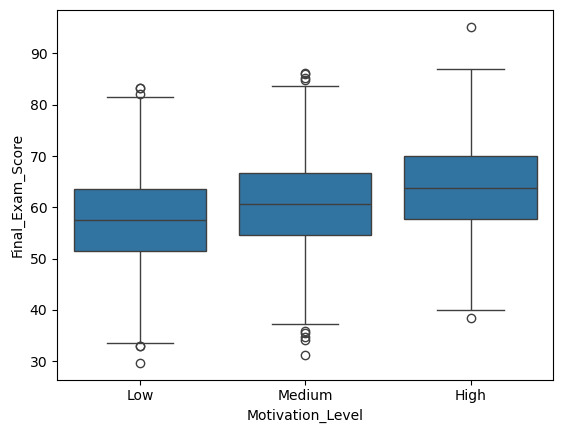

In [17]:
sns.boxplot(data=df_raw, x='Motivation_Level',
            y='Final_Exam_Score', order=['Low', 'Medium', 'High'])

## Chart 7 : Pair Plot - understanding the relationship between hours studied, previous scores, final exam score and motivation levels.

***Reason For Using these charts:*** Understanding the importance of each factor with final exam score.
***Expectations:*** Confirmation of our initial hypothesis :

***Results:*** 

**3rd Row , Col 1: Hours studied vs final score & final exam score:** 
---
1. / this shape shows a tight correlation more hours meaning meaning more score.
2. The blue dots (low motivation) at the bottom and the green (high motivation) and orange (medium motivation) on the upper side shows that motivation is doing a lot of heavy lifting ; motivation together with hours gets the best score.
   
**3rd Row, Col 2: Previous scores vs hours studied & final exam score:**
---
1. The relationship her is the strongest and also validates the finding of out correlatio heatmap, the diagmal cloud (/) confirms the strong relatioship.

**3rd column: Final exam score vs hours studied & previous score:**
---
1. A clear pattern cannot be determined from this graph and the messiness of colour confirms that these both categories had almost near-zero correlation.

***Analysis:***
---
1. Students who studied many hours didn't necessarily have high previous scores.
2. Ths strongest relationship is between Previous_Scores & Final_Exam_Score ; confirmed by both heatmap (0.65 correlation) and and the bottom graph's diagnal (/) cloud compared to other subplot.
3. Motivation and hours studied is the biggest factor in determining students' success.

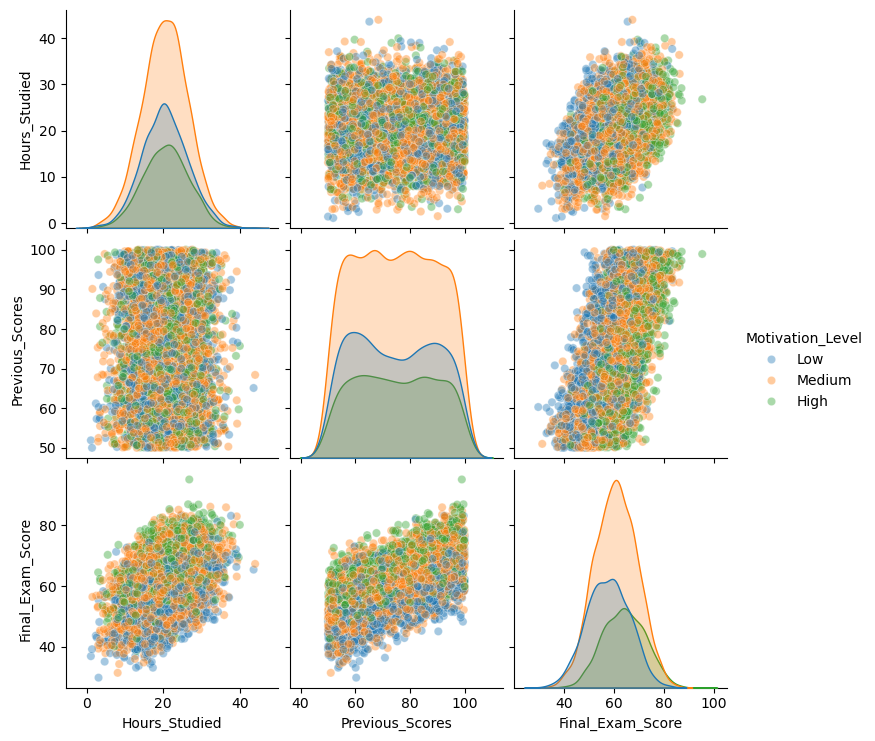

In [18]:
sns.pairplot(df_raw[['Hours_Studied',
                 'Previous_Scores',
                 'Final_Exam_Score', 'Motivation_Level']],
             hue='Motivation_Level',hue_order=['Low', 'Medium', 'High'],
             plot_kws={'alpha':0.4})
plt.show()

## Chart 8 : Grouped Bar - internet vs resources and score

<Axes: xlabel='Access_to_Resources', ylabel='Final_Exam_Score'>

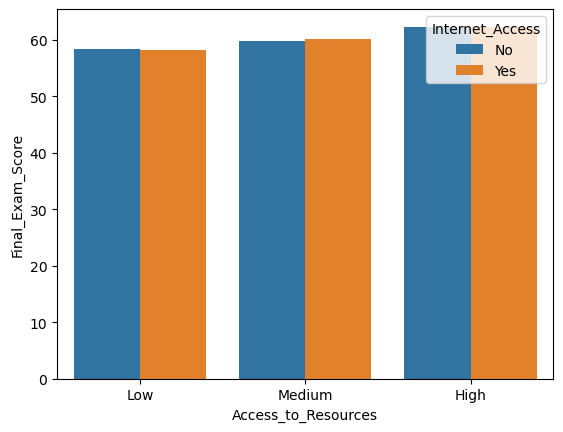

In [19]:
grouped = df_raw.groupby(['Internet_Access', 'Access_to_Resources'])['Final_Exam_Score'].mean().reset_index()
sns.barplot(data=grouped, x='Access_to_Resources',
            y='Final_Exam_Score', hue='Internet_Access',
            order=['Low', 'Medium', 'High'])

## Chart 9: Violin Plot -parental involvement vs final exam score
***Reason for using This Chart:*** To determine if "High" parental involvement students are consistenely highscore of are there underperformers too.

***Findings:*** Students with "low" parental involvement peaked at 60 score, with a very small minority scoring above 80 and below 45.

Students with "Medium" parental involvement also had the most students scoring 60 with steeper curve in above and below range, but students in this range, although in minority but surpassed other parental involvement in scoring more than 80.

Students with High parental involvemnt show the highest bulge at 60 comparing with other parental involvement levels

All three graphs show median at the same score ~ 60.

***Analysis:***
The graphs although undoubtedly different follow the same pattern, peaking at the same score and showing minimum difference in other levels, this confirms our earlier hypothesis that other factors our better predictors of students' academic success

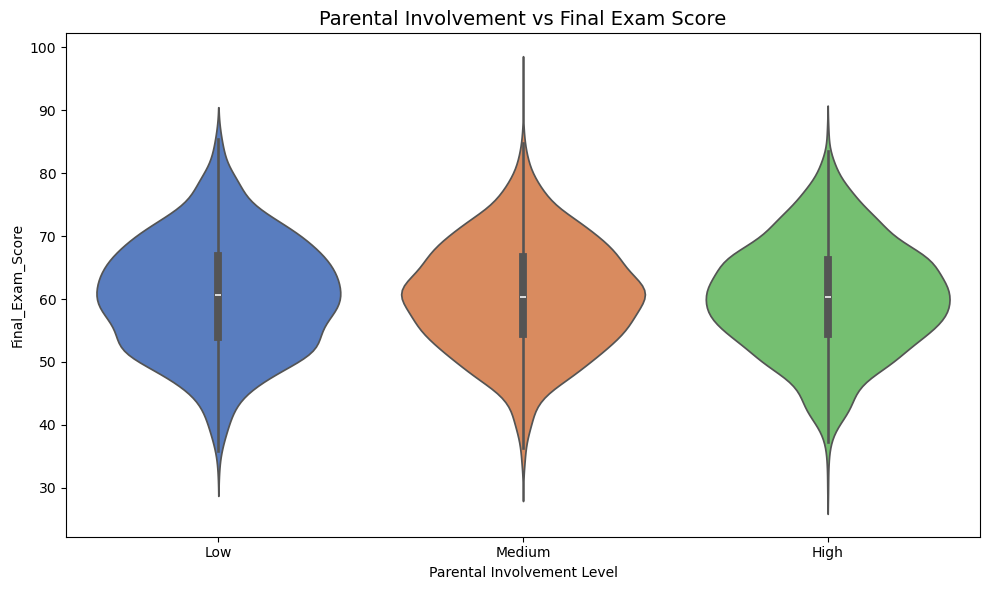

In [20]:
plt.figure(figsize=(10,6))
sns.violinplot(data=df_raw, x='Parental_Involvement',
               y='Final_Exam_Score', order=['Low', 'Medium', 'High'], palette='muted',inner='box') #inner='box' shows median + IQR box
plt.title('Parental Involvement vs Final Exam Score', fontsize=14)                                 #inner='quartile' shows three lines for Q1,median(Q2),Q3
plt.xlabel('Parental Involvement Level')
plt.tight_layout()
plt.show()

## chart 10: Pivot Heatmap - Parental Involvement vs Motivation level and the mean score
***Why use this chart:*** How motivation levels and Parental involvement affect students' academic performance.
***Findings:*** High Parental involvement and low motivation level resulted in the least mean score 57.0

High Parental Involvement and High motivation Level resulted in mean of 63.9

Low Parental Involvement and High motivation level resulted in the mean high of 64.3

Low Parental Involvement and low motivation resulted in 57.6 mean score.

***Analysis:***

The most contradictory part is students struggling with low motivation don't get helped by high parental involvement ; as we can see this particular combination resulted in the least mean score.

Either Increased Parental Involvement lead to low levels of motivation or exacerbates existing negative conditions.

The other most defining part is students with High Motivations and low Parental Involvement scored the highest mean, this contradicts our earlier findings that Parental Involvement positively affects students' performance it may as well negatively affect students performance.


<Axes: xlabel='Parental_Involvement', ylabel='Motivation_Level'>

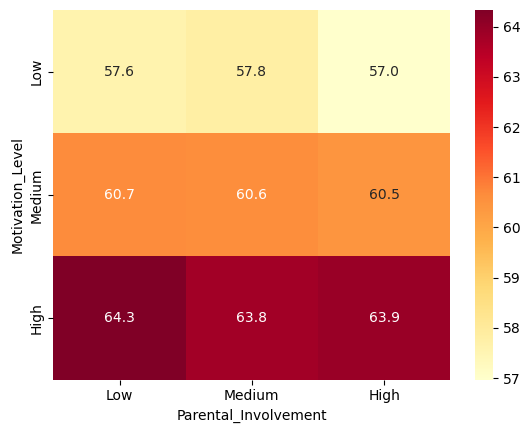

In [21]:
pivot = df_raw.pivot_table(values='Final_Exam_Score',
                           index='Motivation_Level',
                           columns='Parental_Involvement',
                           aggfunc='mean')
pivot = pivot.loc[['Low' , 'Medium', 'High'], ['Low', 'Medium', 'High']]

sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd')